In [1]:
# Initial model (same architecture as `concept.ipynb`)

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from keras.layers import Dense, Input, Embedding, Flatten, Concatenate, Dropout
from keras.models import Model

# Paths: notebook lives in `notebooks/`
_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(_ROOT, "archive")):
    _ROOT = os.getcwd()
TRAIN_PATH = os.path.join(_ROOT, "archive", "train.csv")
TEST_PATH = os.path.join(_ROOT, "archive", "test.csv")

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# Foot: same mapping as concept (right=0, left=1, both=2)
train["foot"] = train["foot"].map({"right": 0, "left": 1, "both": 2})
test["foot"] = test["foot"].map({"right": 0, "left": 1, "both": 2})

# Drop rows missing fields needed for the model (mirrors concept's dropna approach)
req = [
    "player_age",
    "height_in_cm",
    "foot",
    "team_id",
    "goals_per_90",
    "assists_per_90",
    "country_of_citizenship",
    "player_pos",
    "market_val_amnt",
    "age_sq",
    "has_appearance_history",
    "has_buying_club_history",
]
train = train.dropna(subset=req).copy()
test = test.dropna(subset=req).copy()

# Target: log1p(market value) like concept's log1p(market_value_in_eur)
y_train = np.log1p(train["market_val_amnt"].values)
y_test = np.log1p(test["market_val_amnt"].values)

In [3]:
# Label encoders fit on TRAIN only; reserve last index for unseen test categories
MISS = "__missing__"


def fit_cat_encoder(series: pd.Series) -> LabelEncoder:
    le = LabelEncoder()
    le.fit(series.astype(str).fillna(MISS))
    return le


def encode_cat(le: LabelEncoder, series: pd.Series) -> np.ndarray:
    classes = set(le.classes_)
    unk = len(le.classes_)
    s = series.astype(str).fillna(MISS)
    return np.array([le.transform([x])[0] if x in classes else unk for x in s], dtype=np.int64)


le_country = fit_cat_encoder(train["country_of_citizenship"])
le_position = fit_cat_encoder(train["player_pos"])

c_train = encode_cat(le_country, train["country_of_citizenship"])
c_test = encode_cat(le_country, test["country_of_citizenship"])
p_train = encode_cat(le_position, train["player_pos"])
p_test = encode_cat(le_position, test["player_pos"])

# Numeric features: 9 inputs analogous to concept
# (age, height, foot, club id, goals, assists, …) — here we use per-90 stats + age_sq + history flags
# instead of card/minute totals, which are not in this dataset.
num_cols = [
    "player_age",
    "height_in_cm",
    "foot",
    "team_id",
    "goals_per_90",
    "assists_per_90",
    "age_sq",
    "has_appearance_history",
    "has_buying_club_history",
]
Xn_train = train[num_cols].values.astype(np.float64)
Xn_test = test[num_cols].values.astype(np.float64)

scaler = StandardScaler()
Xn_train = scaler.fit_transform(Xn_train)
Xn_test = scaler.transform(Xn_test)

c_train = c_train.reshape(-1, 1)
c_test = c_test.reshape(-1, 1)
p_train = p_train.reshape(-1, 1)
p_test = p_test.reshape(-1, 1)

n_country = len(le_country.classes_) + 1  # unknown bucket
n_position = len(le_position.classes_) + 1

In [4]:
num_input = Input(shape=(Xn_train.shape[1],))
country_input = Input(shape=(1,))
position_input = Input(shape=(1,))

country_embedding = Embedding(input_dim=n_country, output_dim=8)(country_input)
position_embedding = Embedding(input_dim=n_position, output_dim=8)(position_input)

country_embedding = Flatten()(country_embedding)
position_embedding = Flatten()(position_embedding)

x = Concatenate()([num_input, country_embedding, position_embedding])
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1)(x)

model = Model(inputs=[num_input, country_input, position_input], outputs=output)
model.compile(optimizer="adam", loss="mse")

model.fit(
    [Xn_train, c_train, p_train],
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=([Xn_test, c_test, p_test], y_test),
)

y_pred_log = model.predict([Xn_test, c_test, p_test], verbose=0)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 1000us/step - loss: 135.6386 - val_loss: 12.1469
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 12.8556 - val_loss: 5.5042
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 9.5953 - val_loss: 4.1192
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 8.4901 - val_loss: 3.5338
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 7.8517 - val_loss: 4.4469
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 7.6045 - val_loss: 3.1594
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 7.1038 - val_loss: 2.8961
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 6.8344 - val_loss: 2.8253
Epoch 9/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - loss: 6.5957 - val_loss: 2.6615
Epoch 10/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 6.7357 - val_loss: 2.8725
MSE: 244462315303764.28
R2 Score: -0.2671029925091324


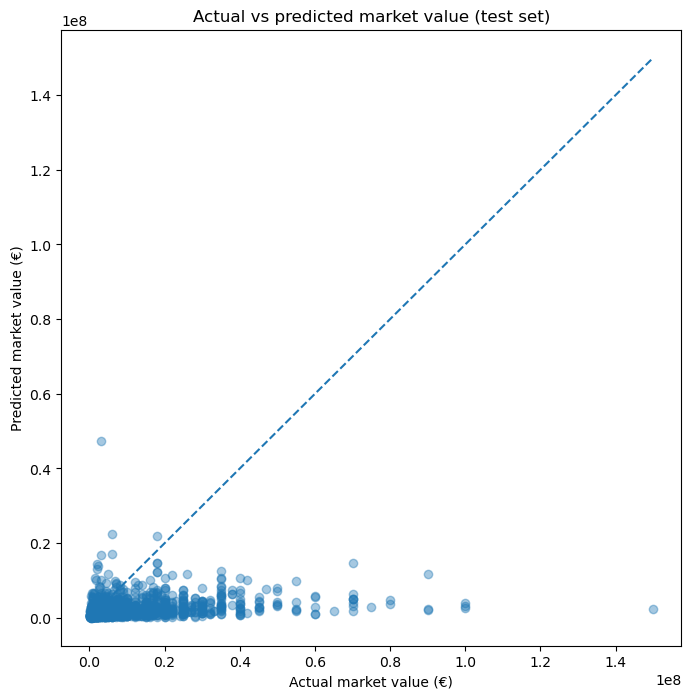

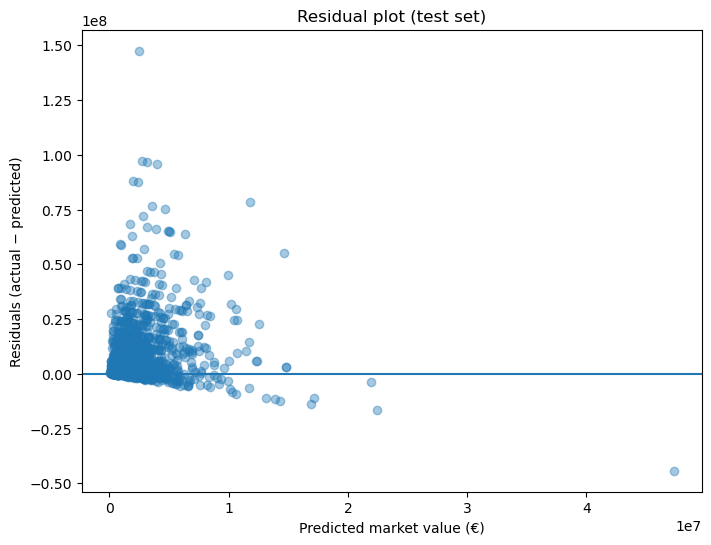

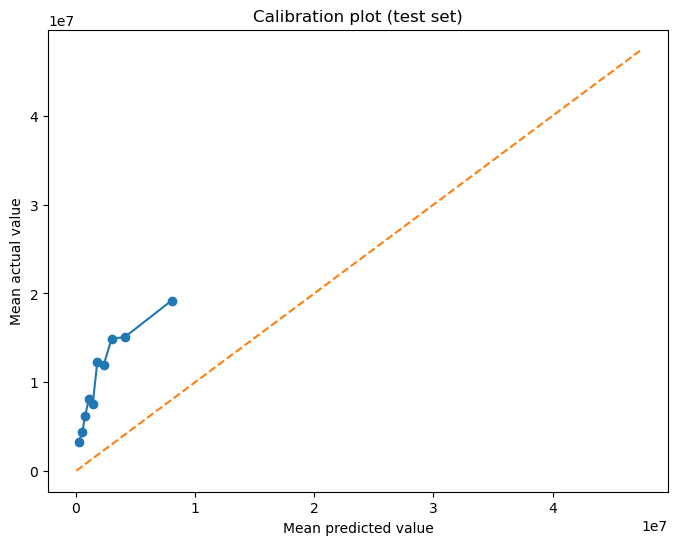

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.4)
max_val = max(np.max(y_true), np.max(y_pred))
min_val = min(np.min(y_true), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual market value (€)")
plt.ylabel("Predicted market value (€)")
plt.title("Actual vs predicted market value (test set)")
plt.show()

residuals = y_true - y_pred.flatten()
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted market value (€)")
plt.ylabel("Residuals (actual − predicted)")
plt.title("Residual plot (test set)")
plt.show()

df_cal = pd.DataFrame({"y_true": y_true, "y_pred": y_pred.flatten()})
df_cal["bin"] = pd.qcut(df_cal["y_pred"], q=10, duplicates="drop")
calibration = df_cal.groupby("bin", observed=True).mean()
plt.figure(figsize=(8, 6))
plt.plot(calibration["y_pred"], calibration["y_true"], marker="o")
plt.plot(
    [df_cal["y_pred"].min(), df_cal["y_pred"].max()],
    [df_cal["y_pred"].min(), df_cal["y_pred"].max()],
    linestyle="--",
)
plt.xlabel("Mean predicted value")
plt.ylabel("Mean actual value")
plt.title("Calibration plot (test set)")
plt.show()